# Search the entire CDA with keywords


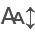

In [ ]:
import numpy as np
import pandas as pd
from itables import init_notebook_mode, show
init_notebook_mode(all_interactive=True)
import itables.options as opt

opt.classes="display nowrap compact"
opt.buttons=["copyHtml5", "csvHtml5", "excelHtml5"]
opt.maxBytes=0
opt.columnDefs = [{"className": "dt-left", "targets": "_all"}]

from cdapython import *

I'm a grad student, and I don't have a lot of money available to run new experiments. I want to see what data is available that I can use for the bulk of my research to minimize costs. I'm interested in kidney cancer, but haven't locked in a topic yet, so I'd just like to explore.

Since I don't really know what I'm looking for, I want to just put in some key words an see what data pops up. I'm going to start with summaries, because those are easy to browse. 

In [4]:
summarize_subjects( 'kidney' )

╔═══════════════════════════════╗
║ number_of_matching_subjects   ║
╠═══════════════════════════════╣
║ 3499                          ║
╚═══════════════════════════════╝
╔════════════════════════════════════════════════╗
║ number_of_files_related_to_matching_subjects   ║
╠════════════════════════════════════════════════╣
║ 171777                                         ║
╚════════════════════════════════════════════════╝
╔════════════╦══════════════════════╗
║   subjects ║          data_source ║
╠════════════╬══════════════════════╣
║       1285 ║             GDC only ║
║        966 ║            GDC + IDC ║
║        791 ║             IDC only ║
║        121 ║      PDC + GDC + IDC ║
║        112 ║ PDC + GC + GDC + IDC ║
║        110 ║              GC only ║
║         44 ║       GC + GDC + IDC ║
║         29 ║            PDC + GDC ║
║         25 ║             PDC only ║
║         11 ║             GC + IDC ║
║          3 ║           ICDC + IDC ║
║          1 ║            ICDC only ║
║    

There are about 3500 subjects that have clinical data or file data that is tagged with kidney. It has searched every column, but the summary results don't display every column. I'm goint to run the `columns()` command to see what columns are available, and add interesting sounding ones to my search:

In [6]:
columns()

table                   column data_type  nullable  \
0                   file                  file_id      text     False   
1                   file                   access      text      True   
2                   file            anatomic_site      text     False   
3                   file                 category      text      True   
4                   file                  drs_uri      text      True   
..                   ...                      ...       ...       ...   
59             treatment  treatment_anatomic_site      text      True   
60             treatment           treatment_type      text      True   
61  upstream_identifiers              upstream_id      text     False   
62  upstream_identifiers           upstream_field      text     False   
63  upstream_identifiers          upstream_source      text     False   

                                          description  
0   A unique identifier for this file minted by CD...  
1                  Denotes controlled vs open access.  
2   One or more anatomic sites described by this f...  
3   General category of file data. In the case of ...  
4   A resolvable DRS URI minted for this file and ...  
..                                                ...  
59  Anatomic site targeted by this treatment, clas...  
60                       Type of treatment performed.  
61  One identifier, exactly as published by the sp...  
62  What this identifier is called by the specifie...  
63  The upstream data source from which this ident...  

[64 rows x 5 columns]

In [5]:
summarize_subjects( 'kidney', add_columns=['anatomic_site', 'observed_anatomic_site', 'resection_anatomic_site', 'diagnosis', 'morphology', 'format'])

╔═══════════════════════════════╗
║ number_of_matching_subjects   ║
╠═══════════════════════════════╣
║ 3499                          ║
╚═══════════════════════════════╝
╔════════════════════════════════════════════════╗
║ number_of_files_related_to_matching_subjects   ║
╠════════════════════════════════════════════════╣
║ 171777                                         ║
╚════════════════════════════════════════════════╝
╔════════════╦══════════════════════╗
║   subjects ║          data_source ║
╠════════════╬══════════════════════╣
║       1285 ║             GDC only ║
║        966 ║            GDC + IDC ║
║        791 ║             IDC only ║
║        121 ║      GDC + PDC + IDC ║
║        112 ║ GDC + GC + PDC + IDC ║
║        110 ║              GC only ║
║         44 ║       GDC + GC + IDC ║
║         29 ║            GDC + PDC ║
║         25 ║             PDC only ║
║         11 ║             GC + IDC ║
║          3 ║           ICDC + IDC ║
║          1 ║            ICDC only ║
║    

In the `anatomic_site` results, it looks like theres quite a lot of subjects who are also tagged with VCF. That could be interesting, if there is some kind of sequencing data maybe I could do some kind of comparison of mutations or markers  to my search list:

In [22]:
summarize_subjects( 'kidney', 'vcf', add_columns=['anatomic_site', 'observed_anatomic_site', 'resection_anatomic_site', 'diagnosis', 'morphology', 'format'])


╔═══════════════════════════════╗
║ number_of_matching_subjects   ║
╠═══════════════════════════════╣
║ 2451                          ║
╚═══════════════════════════════╝
╔════════════════════════════════════════════════╗
║ number_of_files_related_to_matching_subjects   ║
╠════════════════════════════════════════════════╣
║ 146456                                         ║
╚════════════════════════════════════════════════╝
╔════════════╦══════════════════════╗
║   subjects ║          data_source ║
╠════════════╬══════════════════════╣
║       1195 ║             GDC only ║
║        932 ║            GDC + IDC ║
║        121 ║      GDC + IDC + PDC ║
║        112 ║ GC + GDC + IDC + PDC ║
║         42 ║       GC + GDC + IDC ║
║         29 ║            GDC + PDC ║
║         17 ║              GC only ║
║          3 ║           ICDC + IDC ║
╚════════════╩══════════════════════╝
╔════════════════╦═══════════════════════════════════════════╗
║   count_result ║                                      

At this point, I can keep adding keywords as I go, or I can use the information I've gathered to make a targeted search for just the data I want. So now instead a global keyword search, I'm going to specify I only want kidney values from anatomic site, and I only want vcf from format:

In [23]:
summarize_subjects(match_all=['format = vcf', 'anatomic_site = kidney'])

╔═══════════════════════════════╗
║ number_of_matching_subjects   ║
╠═══════════════════════════════╣
║ 328                           ║
╚═══════════════════════════════╝
╔════════════════════════════════════════════════╗
║ number_of_files_related_to_matching_subjects   ║
╠════════════════════════════════════════════════╣
║ 6035                                           ║
╚════════════════════════════════════════════════╝
╔════════════╦══════════════════════╗
║   subjects ║          data_source ║
╠════════════╬══════════════════════╣
║        121 ║      PDC + IDC + GDC ║
║        110 ║ PDC + IDC + GDC + GC ║
║         50 ║             GDC only ║
║         29 ║            PDC + GDC ║
║         17 ║              GC only ║
║          1 ║            IDC + GDC ║
╚════════════╩══════════════════════╝
╔════════════════╦════════════════════╗
║   count_result ║          ethnicity ║
╠════════════════╬════════════════════╣
║            184 ║               <NA> ║
║            128 ║       Non-Hispan

It looks like most of the subjects also have blood info, I wonder if that could be useful. Instead of summarizing again, I'm going to browse through the row level data for subjects with kidney, blood, and vcf data. Since kidney and blood are both anatomic sites, i'll have to do two searches and take the intersection:

In [28]:
justkidney = get_subject_data(match_all=['format = vcf', 'anatomic_site = kidney'])

In [29]:
justblood = get_subject_data(match_all=['format = vcf', 'anatomic_site = blood'])

In [30]:
intersect_subject_results(justkidney, justblood)

subject_id cause_of_death     ethnicity  \
0              CCDI.689.0           <NA>          <NA>   
1              CCDI.717.0           <NA>          <NA>   
2              CCDI.826.0           <NA>  Non-Hispanic   
3          CCDI.TB-000084           <NA>  Non-Hispanic   
4          CCDI.TB-000085           <NA>  Non-Hispanic   
..                    ...            ...           ...   
305  MP2PRT.MP2PRT-PAXELC           <NA>  Non-Hispanic   
306  MP2PRT.MP2PRT-PAXMWW           <NA>  Non-Hispanic   
307  MP2PRT.MP2PRT-PAYJBH           <NA>  Non-Hispanic   
308  MP2PRT.MP2PRT-PAYTJD           <NA>  Non-Hispanic   
309  MP2PRT.MP2PRT-PAZEPC           <NA>          <NA>   

                          race species year_of_birth year_of_death  \
0                         <NA>    <NA>          <NA>          <NA>   
1                         <NA>    <NA>          <NA>          <NA>   
2                         <NA>    <NA>          <NA>          <NA>   
3                        White   human          <NA>          <NA>   
4                        White   human          <NA>          <NA>   
..                         ...     ...           ...           ...   
305  Black or African American   human          2004          <NA>   
306                      White   human          2000          <NA>   
307                      White   human          2014          <NA>   
308                      White   human          2011          <NA>   
309  Black or African American   human          2017          <NA>   

    data_source format             anatomic_site  
0          [GC]  [VCF]           [blood, kidney]  
1          [GC]  [VCF]           [blood, kidney]  
2          [GC]  [VCF]           [blood, kidney]  
3          [GC]  [VCF]           [blood, kidney]  
4          [GC]  [VCF]           [blood, kidney]  
..          ...    ...                       ...  
305       [GDC]  [VCF]  [abdomen, blood, kidney]  
306       [GDC]  [VCF]     [blood, kidney, lung]  
307       [GDC]  [VCF]  [abdomen, blood, kidney]  
308       [GDC]  [VCF]     [blood, kidney, lung]  
309       [GDC]  [VCF]           [blood, kidney]  

[310 rows x 10 columns]

Now I have just the 310 subjects with kidney, blood, and vcf. But I wonder if there are VCFs for both the blood and kidney. I can change my most recent search to get that info added too. Since I want to map each VCF to an anatomic site, I need to add all the file columns to my search, and have them collated. Then I expand the intersected results:

In [41]:
justkidney = get_subject_data(match_all=['format = vcf', 'anatomic_site = kidney'], add_columns='file.*', collate_results = True)
justblood = get_subject_data(match_all=['format = vcf', 'anatomic_site = blood'], add_columns='file.*', collate_results = True)
expand_subject_results(intersect_subject_results(justkidney, justblood), 'file_data')

subject_id data_source  \
0               CCDI.689.0          GC   
1               CCDI.689.0          GC   
2               CCDI.689.0          GC   
3               CCDI.689.0          GC   
4               CCDI.717.0          GC   
...                    ...         ...   
6130  MP2PRT.MP2PRT-PAZEPC         GDC   
6131  MP2PRT.MP2PRT-PAZEPC         GDC   
6132  MP2PRT.MP2PRT-PAZEPC         GDC   
6133  MP2PRT.MP2PRT-PAZEPC         GDC   
6134  MP2PRT.MP2PRT-PAZEPC         GDC   

                                           file_id      access anatomic_site  \
0     dg.4DFC/af5e4fbd-0a4e-461b-b3da-07c86238926f  controlled      [kidney]   
1     dg.4DFC/b23e5140-3d0c-4232-a01f-373d3d349a09  controlled      [kidney]   
2     dg.4DFC/3c478c8c-dd2e-4d99-86e9-c827541b2768  controlled      [kidney]   
3     dg.4DFC/37c7e89d-14ec-49d9-830c-302266f24e95  controlled       [blood]   
4     dg.4DFC/aed48658-fffd-4a7c-abe2-3f120edf799d  controlled      [kidney]   
...                                            ...         ...           ...   
6130          dd156a60-c869-4f4d-b3a1-3323832b5c45  controlled       [blood]   
6131          37319bc5-a67b-48b5-9b74-1ce73a2ee72e  controlled       [blood]   
6132          62720571-396a-4b60-bebe-015cd4ad6f17  controlled       [blood]   
6133          c1882673-834e-43e0-b67a-097954a51581  controlled       [blood]   
6134          cb18fb80-443d-4a39-b5bb-1d41470f5ee2  controlled       [blood]   

                          category  \
0                              WGS   
1                              WGS   
2                              WGS   
3                              WGS   
4                              WGS   
...                            ...   
6130   Simple Nucleotide Variation   
6131   Simple Nucleotide Variation   
6132   Simple Nucleotide Variation   
6133  Somatic Structural Variation   
6134  Somatic Structural Variation   

                                                drs_uri file_description  \
0     drs://dg.4dfc/af5e4fbd-0a4e-461b-b3da-07c86238...             <NA>   
1     drs://dg.4dfc/b23e5140-3d0c-4232-a01f-373d3d34...             <NA>   
2     drs://dg.4dfc/3c478c8c-dd2e-4d99-86e9-c827541b...             <NA>   
3     drs://dg.4dfc/37c7e89d-14ec-49d9-830c-302266f2...             <NA>   
4     drs://dg.4dfc/aed48658-fffd-4a7c-abe2-3f120edf...             <NA>   
...                                                 ...              ...   
6130  drs://dg.4dfc:dd156a60-c869-4f4d-b3a1-3323832b...             <NA>   
6131  drs://dg.4dfc:37319bc5-a67b-48b5-9b74-1ce73a2e...             <NA>   
6132  drs://dg.4dfc:62720571-396a-4b60-bebe-015cd4ad...             <NA>   
6133  drs://dg.4dfc:c1882673-834e-43e0-b67a-097954a5...             <NA>   
6134  drs://dg.4dfc:cb18fb80-443d-4a39-b5bb-1d41470f...             <NA>   

                                              file_name  \
0                            UCPG-689_3T.ccdi.sv.vcf.gz   
1                           UCPG-689_3T.ccdi.seg.txt.gz   
2                           UCPG-689_3T.ccdi.var.vcf.gz   
3                          UCPG-689_5G.ccdi.germ.vcf.gz   
4                            UCPG-717_4T.ccdi.sv.vcf.gz   
...                                                 ...   
6130  32b737a7-1f07-40d2-bb05-94c0233ce0f8.wgs.sange...   
6131  32b737a7-1f07-40d2-bb05-94c0233ce0f8.wgs.CaVEM...   
6132  MP2PRT-WT.27ff4344-87ce-4ae8-be2a-1763e8b4d6f8...   
6133  32b737a7-1f07-40d2-bb05-94c0233ce0f8.wgs.BRASS...   
6134  4c5ac21f-97b8-4592-aea5-dbb98f571f6f.somatic_s...   

                        file_type format      size  tumor_vs_normal  
0                            <NA>    VCF      3178          [tumor]  
1                            <NA>    VCF      8792          [tumor]  
2                            <NA>    VCF      6894          [tumor]  
3                            <NA>    VCF    115978         [normal]  
4                            <NA>    VCF      3182          [tumor]  
...                           ...    ...       ... 

now I have one row per file, and I can see exactly how all the variables relate to one another. For instance, subject `CCDI.689.0	` has four WGS files, three are kidney and one is blood. If all the subjects have both kidney and blood WGS, maybe I can look for organ specific mutations.